# House Prices: EDA (Exploratory Data Analysis)
This notebook focuses on understanding the data, identifying patterns, and discovering insights that will guide feature engineering and modeling decisions.

## **Key Questions to Answer:**
1. What is the distribution of SalePrice? Is it skewed?
2. Which features have the strongest correlation with SalePrice?
3. What is the pattern of missing values? (Real missing vs. absence of feature)
4. Are there outliers that might affect modeling?
5. What are the relationships between categorical features and SalePrice?

In [27]:
# Import libraries
import sys
sys.path.append('../')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Taken from Deepseek src helper functions
from src.utils import (
    load_data, plot_sale_price_distribution, analyze_missing_values,
    identify_na_as_absence_columns, replace_na_with_none,
    numeric_vs_categorical_split, plot_correlation_with_target,
    plot_categorical_impact
)

# Set display options
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 50)

In [28]:
# Load data
train, test, sample = load_data("../data/")

# Create a copy for EDA (keeping original untouched)
df_train = train.copy()
df_test = test.copy()

print("\nDataset Info:")
print(f"Training set: {df_train.shape[0]} rows, {df_train.shape[1]} columns")
print(f"Test set: {df_test.shape[0]} rows, {df_test.shape[1]} columns")

Train shape: (1460, 81)
Test shape: (1459, 80)
Sample submission shape: (1459, 2)

Dataset Info:
Training set: 1460 rows, 81 columns
Test set: 1459 rows, 80 columns


## 1. Target Variable Analysis (SalePrice)

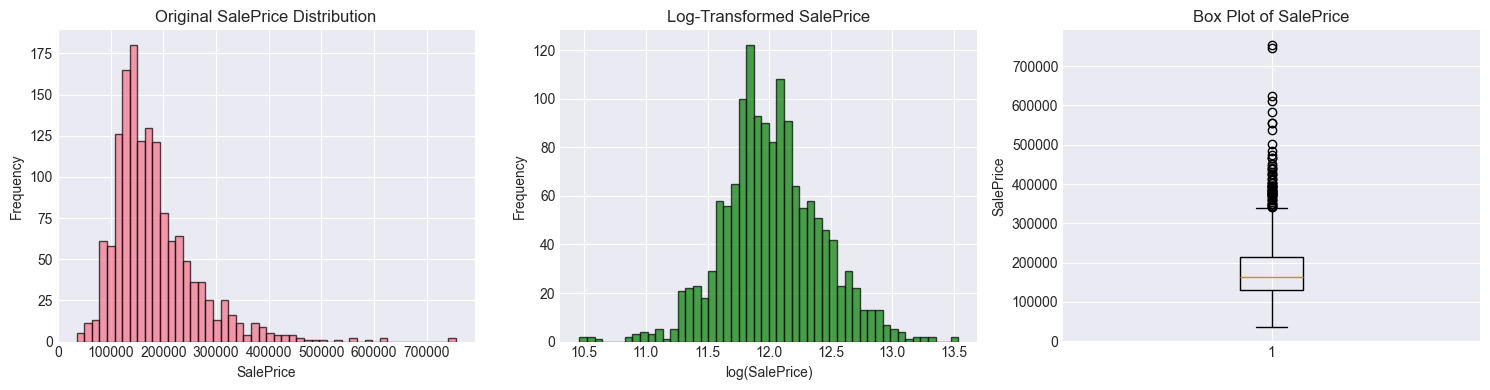

Skewness (original): 1.883
Skewness (log transformed): 0.121

SalePrice Statistics:
count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

Number of houses with SalePrice <= 0: 0


In [31]:
# Analyze SalePrice distribution
log_prices = plot_sale_price_distribution(df_train, save_path="../reports/sale_price_distribution.png")

# Check basic statistics
print("\nSalePrice Statistics:")
print(df_train['SalePrice'].describe())

# Check for zero or negative values (should not exist for house prices)
print(f"\nNumber of houses with SalePrice <= 0: {(df_train['SalePrice'] <= 0).sum()}")

**Key Insight (Bryce):** 
1. SalePrice is right-skewed (Positive skew, Skewness: 1.883 ). Log transformation looks to have helped it normalise (Skewness 0.121)
2. No Negative house prices (Good)

## 2. Missing Values Analysis

In [32]:
# First, let's understand which NA values are actually "absence" indicators
absence_cols = identify_na_as_absence_columns()
print(f"Columns where NA means 'absence of feature':\n{absence_cols}\n")

# Check missing values BEFORE replacing NA with 'None'
print("=== Missing Values BEFORE Processing ===")
missing_before = analyze_missing_values(df_train)
print(missing_before.to_string(index=False))

Columns where NA means 'absence of feature':
['Alley', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PoolQC', 'Fence', 'MiscFeature']

=== Missing Values BEFORE Processing ===
      Column  Missing_Count  Missing_Percent
      PoolQC           1453        99.520548
 MiscFeature           1406        96.301370
       Alley           1369        93.767123
       Fence           1179        80.753425
  MasVnrType            872        59.726027
 FireplaceQu            690        47.260274
 LotFrontage            259        17.739726
  GarageType             81         5.547945
 GarageYrBlt             81         5.547945
GarageFinish             81         5.547945
  GarageQual             81         5.547945
  GarageCond             81         5.547945
BsmtExposure             38         2.602740
BsmtFinType2             38         2.602740
    BsmtQual             37         2.534247
    